#### Inverse kinematics of `Panda` bookshelf environment

In [1]:
%run ../../package/init_scripts/init_dev_env.py
from package.panda_env import * 


Initializing development environment with [9] scripts

[0/9] Calling [init_ipython_setup.py]
Basic packages initialized.
 import numpy as np
 import matplotlib.pyplot as plt
 import scipy as sp
 from PIL import Image
[ipython] settings (retina, inline, qt) initialized.
[numpy] settings initialized.
[matplotlib] settings initialized.

[1/9] Calling [init_utility.py]
[utility] package initialized.
 from utils import *
 from viz import *
 from filters import *

[2/9] Calling [init_kinematics.py]
[kinematics] package initialized.
 from transforms import *
 from numpy_chain import *

[3/9] Calling [init_mujoco_sim.py]
[mujoco_sim] package initialized.
 mujoco version: (3, 4, 0)
 from parser import *
 from mujoco_utils import *
 from mujoco_draw import *
 from mujoco_ik import *

[4/9] Calling [init_qt.py]
[qt] package initialized.

[5/9] Calling [init_gaussian_process.py]
[gaussian_process] package initialized.
 from kernels import *
 from gp_utils import *

[6/9] Calling [init_mocap.py]
[m

In [2]:
xml_path = merge_mjcfs(
    included_mjcf_files=[
        '../../asset/floor/floor_white_gray.xml',
        './asset/panda_inspire/panda_inspire_site_added.xml',
        './asset/bookshelf/bookshelf_base.xml',
        './asset/bookshelf/bookshelf_deep.xml',
        './asset/object/cylinder.xml',
    ],
    output_xml_path = 'xml/panda_scene.xml',
)
env = MuJoCoParser(rel_xml_path=xml_path,verbose=True)

[merge_mjcfs] Merging [5] MJCF files:
  - [0] [../../asset/floor/floor_white_gray.xml]
  - [1] [./asset/panda_inspire/panda_inspire_site_added.xml]
  - [2] [./asset/bookshelf/bookshelf_base.xml]
  - [3] [./asset/bookshelf/bookshelf_deep.xml]
  - [4] [./asset/object/cylinder.xml]
[merge_mjcfs] Saved merged XML to:[xml/panda_scene.xml]

-----------------------------------------------------------------------------
name:[scene] dt:[0.002] HZ:[500]
 n_q:[26] n_v:[25] n_u:[7]
 integrator:[IMPLICITFAST]

Body information. n_body:[29]
 [0/29] [world] parent:[world] mass:[0.00]kg
 [1/29] [panda_base] parent:[world] mass:[0.00]kg
 [2/29] [panda_link_0] parent:[panda_base] mass:[4.00]kg
 [3/29] [panda_link_1] parent:[panda_link_0] mass:[3.00]kg
 [4/29] [panda_link_2] parent:[panda_link_1] mass:[3.00]kg
 [5/29] [panda_link_3] parent:[panda_link_2] mass:[2.00]kg
 [6/29] [panda_link_4] parent:[panda_link_3] mass:[2.00]kg
 [7/29] [panda_link_5] parent:[panda_link_4] mass:[2.00]kg
 [8/29] [panda_link_

2026-03-12 21:56:28.062 python[12396:2222496] TSM AdjustCapsLockLEDForKeyTransitionHandling - _ISSetPhysicalKeyboardCapsLockLED Inhibit


Final RGB image captured.


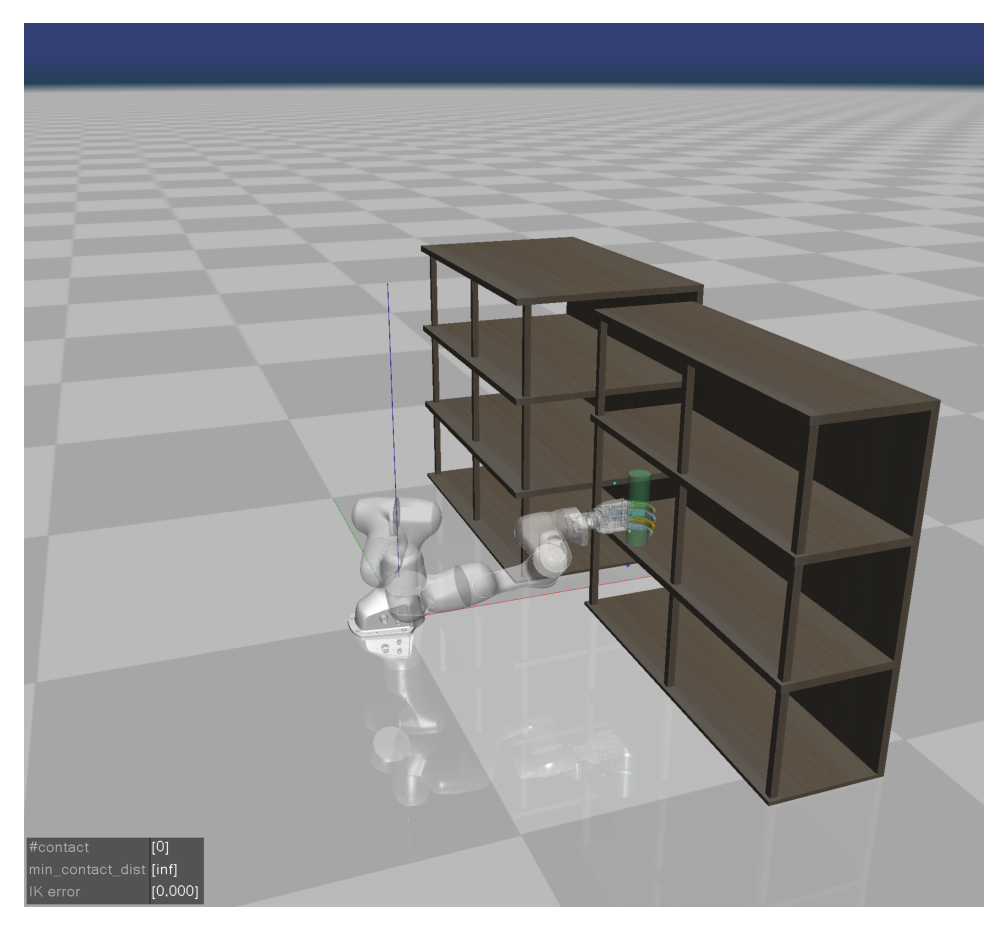

Done.


In [3]:
# Configuration
panda_joints          = get_panda_joint_names()
inspire_joints        = get_inspire_joint_names()
inspire_active_joints = env.get_active_among_joints(inspire_joints)
q_inspire0            = get_q_inspire(env)
p_cylinder_offset0    = get_p_offset_palm_to_cylinder()
q_pandas              = get_q_pandas_bookshelf()

# Initialize env
set_panda_bookshelf_env(env,panda_joints,inspire_joints,q_pandas['right_2f'],q_inspire0)

# Initialize sliders
T_palm    = get_T_palm_panda_inspire(env)
prpy_palm = np.hstack([t2p(T_palm),r2rpy(t2r(T_palm))])
sliders_palm = MultiSliderQtWidget(
    title         = "Panda IK pose target",
    window_width  = 0.2,
    window_height = 0.25,
    label_texts   = ['X','Y','Z','Roll','Pitch','Yaw'],
    slider_mins   = prpy_palm-np.array([1,1,1,180,180,180]),
    slider_maxs   = prpy_palm+np.array([1,1,1,180,180,180]),
    slider_vals   = prpy_palm,
)
sliders_inspire_active = MultiSliderQtWidget(
    title         = "Inspire hand joint position",
    y_offset      = 0.3,
    window_width  = 0.2,
    window_height = 0.2,
    label_texts   = inspire_active_joints,
    slider_mins   = env.get_joint_mins(inspire_active_joints),
    slider_maxs   = env.get_joint_maxs(inspire_active_joints),
    slider_vals   = env.get_qpos(inspire_active_joints),
)
sliders_cylinder_offset = MultiSliderQtWidget(
    title         = "Hand-to-cylinder position offset",
    y_offset      = 0.5,
    window_width  = 0.2,
    window_height = 0.1,
    label_texts   = ['X','Y','Z'],
    slider_mins   = p_cylinder_offset0-0.5*np.ones(3),
    slider_maxs   = p_cylinder_offset0+0.5*np.ones(3),
    slider_vals   = p_cylinder_offset0,
)

# Initialize buttons
buttons = MultiRadioQtWidget(
    title         = "Set Panda joint position",
    label_texts   = ["Panda pose"],
    option_texts  = [["q_right_2f","q_right_3f","q_left_2f","q_left_3f"]],
    initial_texts = ["q_right_2f"],
    y_offset      = 0.6,
    window_width  = 0.2,
    window_height = 0.05,
)

# Initialize IK solver (RevPriBase)
ik_env = MuJoCoParser(rel_xml_path=env.rel_xml_path) # separate env for IK
ik_solver = SitePositionIKSolverRevPriBase(
    ik_env            = ik_env,
    max_ik_tick       = 100,
    ik_stepsize_rev   = 0.5,      # [rad]
    ik_stepsize_pri   = 0.02,     # [m]
    ik_update_th_rev      = 10*D2R,
    dls_damping       = 1e-4,
    max_probe_rev     = 3*D2R,    # [rad]
    max_probe_pri     = 0.01,     # [m]
    k_null            = 0.1,
    q_home_rev_pri    = env.get_qpos(joint_names=env.rev_pri_joint_names),
)

# Loop
while env.is_viewer_alive():

    # Set Panda joint position
    if buttons.is_toggled(label_text="Panda pose"):
        panda_pose = buttons.get_option("Panda pose")
        if panda_pose=="q_right_2f": env.forward(q=q_pandas['right_2f'],joint_names=panda_joints)
        if panda_pose=="q_right_3f": env.forward(q=q_pandas['right_3f'],joint_names=panda_joints)
        if panda_pose=="q_left_2f":  env.forward(q=q_pandas['left_2f'],joint_names=panda_joints)
        if panda_pose=="q_left_3f":  env.forward(q=q_pandas['left_3f'],joint_names=panda_joints)
        T_palm = get_T_palm_panda_inspire(env)
        sliders_palm.set_values(values=np.hstack((t2p(T_palm),r2rpy(t2r(T_palm)))))

    # Solve IK (same helper, new solver)
    p_palm_trgt = sliders_palm.get_values()[:3]
    R_palm_trgt = rpy2r(sliders_palm.get_values()[3:]*D2R)
    ik_err_best = solve_ik_panda_palm(env,ik_solver,p_palm_trgt,R_palm_trgt)

    # FK inspire hand (active -> full -> FK)
    qactive_inspire = sliders_inspire_active.get_values()
    q_inspire = env.get_qfull_from_qactive(
        full_joints   = inspire_joints,
        active_joints = inspire_active_joints,
        qactive       = qactive_inspire,
    )
    env.forward(q=q_inspire,joint_names=inspire_joints)

    # Move attached cylinder
    T_palm = get_T_palm_panda_inspire(env)
    p_cylinder_offset = sliders_cylinder_offset.get_values()
    T_cylinder = view_in_world(T=p2t(p_cylinder_offset),T_wl=T_palm)
    env.set_T('body_cylinder','base_body',T_cylinder)

    # Get contact information (after FK)
    contact_info = env.get_contact_info()

    # Render
    env.viewer_text_overlay('#contact','[%d]'%(contact_info['n_contact']))
    env.viewer_text_overlay('min_contact_dist','[%.3f]'%(contact_info['min_contact_dist']))
    env.viewer_text_overlay('IK error','[%.3f]'%(ik_err_best))
    env.plot_global_coordinate_axes()
    env.plot_contact_info()
    ik_solver.render(env,r=0.005,alpha=0.5,scale_radius_by_weight=True)
    env.render()

# Final image show
imshow(env.final_rgb_img)

# Close
sliders_palm.close()
sliders_inspire_active.close()
sliders_cylinder_offset.close()
buttons.close()
print("Done.")
